In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
df = pd.read_csv("/content/drug200.csv")

In [3]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [9]:
df[df.duplicated()]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug


In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [13]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Sex
M    104
F     96
Name: count, dtype: int64


[]

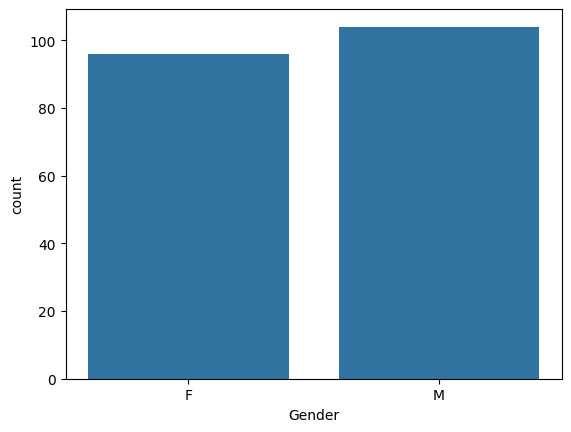

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data = df,x=df['Sex'])
plt.xlabel('Gender')
print(df['Sex'].value_counts())
plt.plot()

In [34]:
df['Drug'].unique()


array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

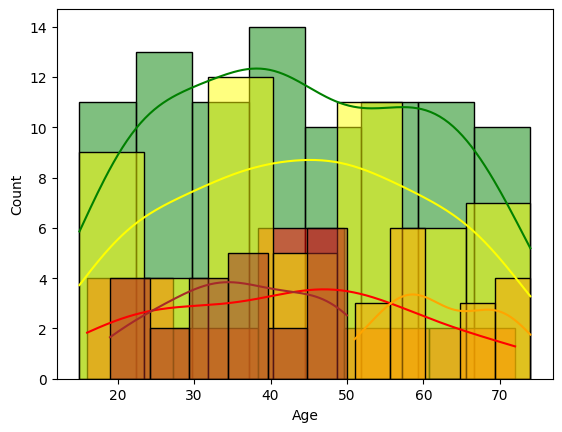

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df[df['Drug'] == 'DrugY']['Age'], color='green', kde=True)
sns.histplot(df[df['Drug'] == 'drugC']['Age'], color='red', kde=True)
sns.histplot(df[df['Drug'] == 'drugX']['Age'], color='yellow', kde=True)
sns.histplot(df[df['Drug'] == 'drugA']['Age'], color='brown', kde=True)
sns.histplot(df[df['Drug'] == 'drugB']['Age'], color='orange', kde=True)
plt.show()


In [20]:
df['Sex_oe'] = oe.fit_transform(df[['Sex']])
df['BP_oe'] = oe.fit_transform(df[['BP']])
df['Cholesterol_oe'] = oe.fit_transform(df[['Cholesterol']])
df['Na_to_K_oe'] = oe.fit_transform(df[['Na_to_K']])
df['Drug_oe'] = oe.fit_transform(df[['Drug']])
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex_oe,BP_oe,Cholesterol_oe,Na_to_K_oe,Drug_oe
0,23,F,HIGH,HIGH,25.355,DrugY,0.0,0.0,0.0,167.0,0.0
1,47,M,LOW,HIGH,13.093,drugC,1.0,1.0,0.0,89.0,3.0
2,47,M,LOW,HIGH,10.114,drugC,1.0,1.0,0.0,43.0,3.0
3,28,F,NORMAL,HIGH,7.798,drugX,0.0,2.0,0.0,10.0,4.0
4,61,F,LOW,HIGH,18.043,DrugY,0.0,1.0,0.0,133.0,0.0


In [73]:
X = df.drop(['Sex', 'BP', 'Cholesterol', 'Drug','Drug_oe'], axis=1)
y = df['Drug_oe']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)


In [74]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [75]:

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


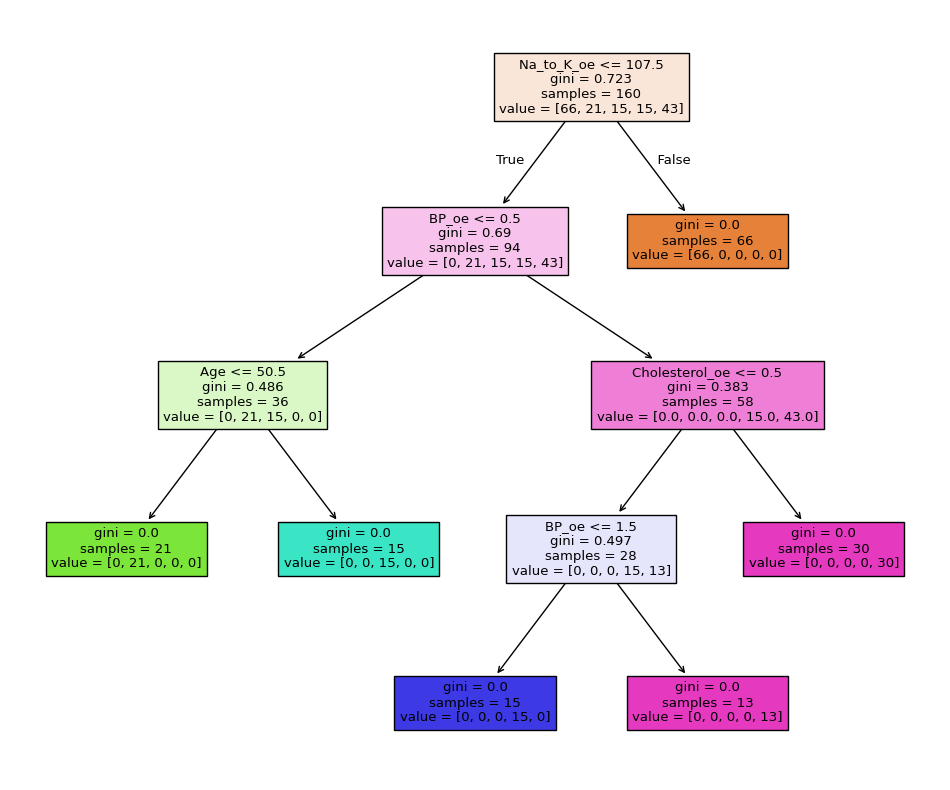

In [76]:
plt.figure(figsize=(12,10))

plot_tree(
    model,
    filled=True,
    feature_names=X_train.columns
)

plt.show()